# 00 - Data collection

Collect rule-based GreenLight-Gym2 trajectories used by later notebooks. The collected data include states, weather, time encoding and actuator actions. Keep `FAST_MODE=True` for a quick smoke run; switch it to `False` for article-grade experiments.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd().resolve()
if (HERE / 'article_experiment_utils.py').exists():
    ARTICLE_DIR = HERE
    REPO_DIR = HERE.parent
else:
    ARTICLE_DIR = HERE / 'own-article'
    REPO_DIR = HERE

sys.path.insert(0, str(ARTICLE_DIR))
sys.path.insert(0, str(REPO_DIR))

from article_experiment_utils import *

OUT = results_dir()
OUT

WindowsPath('C:/Users/zergu/repos/greenhouse-control/own-article/results_scenarios')

In [2]:
FAST_MODE = False

cfg = ExperimentConfig(
    start_date='2010-02-28',
    n_days=7 if FAST_MODE else 60,
    period=900,
    horizon=20,
    seed=42,
    noise_scale=0.1,
    noise_period=5,
)

test_cfg = ExperimentConfig(**{**asdict(cfg), 'start_date': '2010-04-15', 'n_days': 3 if FAST_MODE else 30})

cfg, test_cfg

(ExperimentConfig(env_id='gl_gym/GreenLightTomato-v0', location='Amsterdam', start_date='2010-02-28', growth_year=None, n_days=60, period=900, horizon=20, seed=42, noise_scale=0.1, noise_period=5),
 ExperimentConfig(env_id='gl_gym/GreenLightTomato-v0', location='Amsterdam', start_date='2010-04-15', growth_year=None, n_days=30, period=900, horizon=20, seed=42, noise_scale=0.1, noise_period=5))

In [3]:
train_path = OUT / 'datasets' / ('rbc_train_fast.npz' if FAST_MODE else 'rbc_train_60d.npz')
test_path = OUT / 'datasets' / ('rbc_test_fast.npz' if FAST_MODE else 'rbc_test_30d_2010_04_15.npz')

if train_path.exists():
    train_data = load_dataset(train_path)
else:
    train_data = collect_rule_based_dataset(cfg)
    save_dataset(train_data, train_path)

if test_path.exists():
    test_data = load_dataset(test_path)
else:
    test_data = collect_rule_based_dataset(test_cfg, start_date=test_cfg.start_date)
    save_dataset(test_data, test_path)

train_data.to_frame().head(), test_data.to_frame().head()

(        t_in         co2         rh  T_out  rad  co2_out     sin_h     cos_h  \
 0  16.500000  417.739319  90.000000    4.2  0.0    400.0  0.000000  1.000000   
 1  13.928975  752.341980  94.703300    4.2  0.0    400.0  0.065403  0.997859   
 2  13.934331  782.821899  92.121872    4.2  0.0    400.0  0.130526  0.991445   
 3  14.312871  679.901428  90.539223    4.2  0.0    400.0  0.195090  0.980785   
 4  14.836262  933.625061  89.198143    4.2  0.0    400.0  0.258819  0.965926   
 
    uBoil      uCO2  uThScr     uVent     uLamp    uBlScr  step  time_h  
 0    1.0  0.896002     1.0  0.094057  0.000000  0.000000     0    0.00  
 1    1.0  0.342283     1.0  0.094056  0.804896  0.869782     1    0.25  
 2    1.0  0.000000     1.0  0.094056  0.804896  0.869782     2    0.50  
 3    1.0  0.894433     1.0  0.094056  0.804896  0.869782     3    0.75  
 4    1.0  0.000000     1.0  0.094056  0.804896  0.869782     4    1.00  ,
         t_in         co2         rh     T_out  rad  co2_out     si

In [4]:
summary = pd.DataFrame([
    {'dataset': 'train', **train_data.meta, 'rows': len(train_data.states)},
    {'dataset': 'test', **test_data.meta, 'rows': len(test_data.states)},
])
save_table(summary, OUT / 'tables' / 'dataset_summary.csv')
summary

,dataset,source,env_id,location,start_date,growth_year,start_day,scenario,n_days,period,seed,noise_scale,noise_period,created_at,rows
0,train,rule_based,gl_gym/GreenLightTomato-v0,Amsterdam,2010-02-28,2010,59,"{'location': 'Amsterdam', 'growth_year': 2010,...",60,900,42,0.1,5,2026-05-31 11:30:37,5760
1,test,rule_based,gl_gym/GreenLightTomato-v0,Amsterdam,2010-04-15,2010,105,"{'location': 'Amsterdam', 'growth_year': 2010,...",30,900,42,0.1,5,2026-05-31 11:30:39,2880


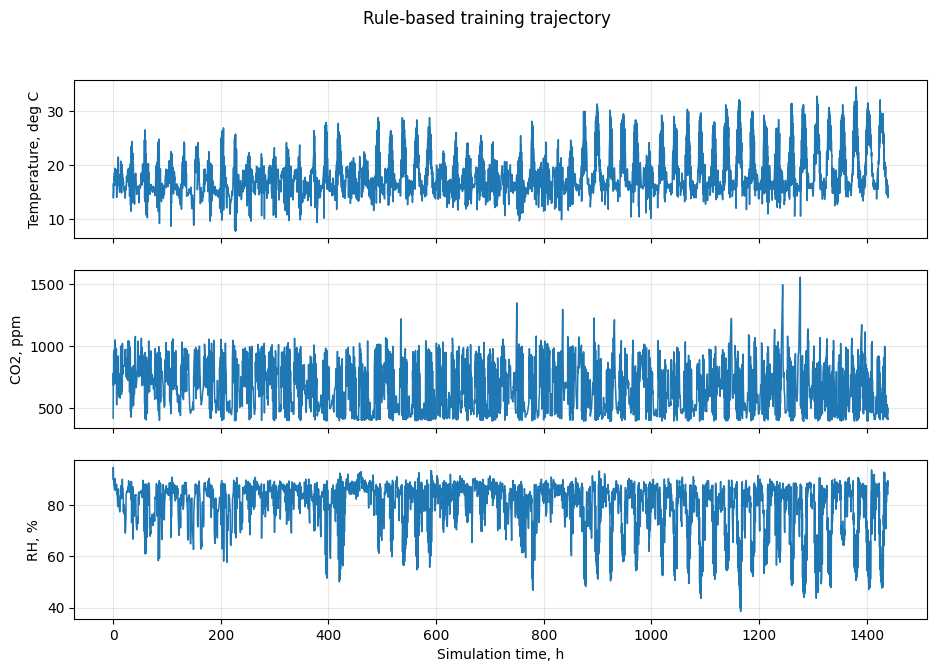

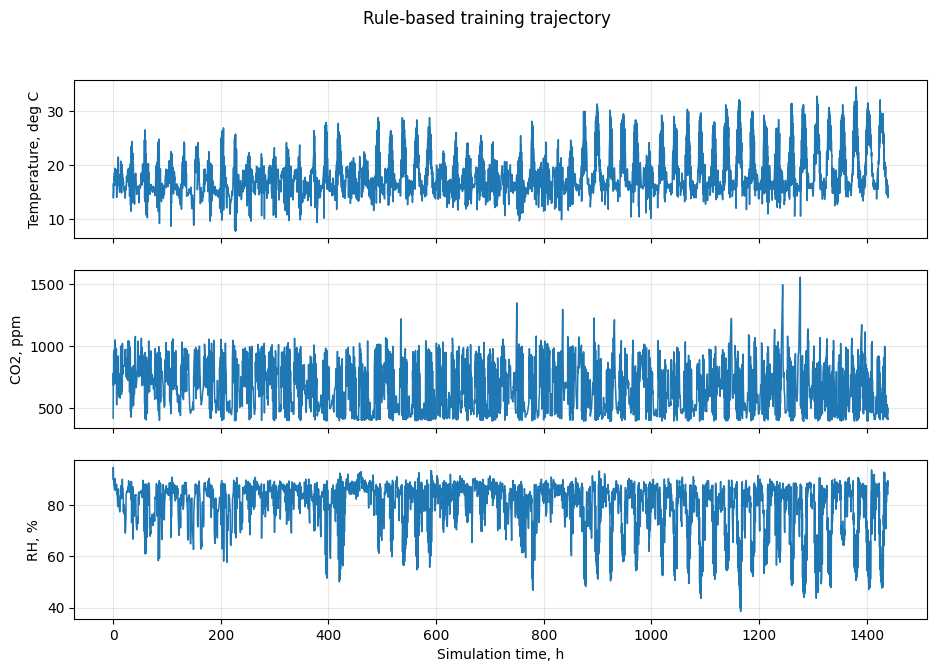

In [5]:
import matplotlib.pyplot as plt

df = train_data.to_frame()
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, col, label in zip(axes, STATE_NAMES, ['Temperature, deg C', 'CO2, ppm', 'RH, %']):
    ax.plot(df['time_h'], df[col], linewidth=1.1)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Simulation time, h')
fig.suptitle('Rule-based training trajectory')
save_figure(fig, OUT / 'figures' / 'dataset_training_states.png')
fig